In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data_csv = pd.read_csv(r"z:\Bel\SeedingThunderGFPHuVEC\vascumap_outputs_new_seg_steps\good_analysis\combined_analysis_metrics.csv")

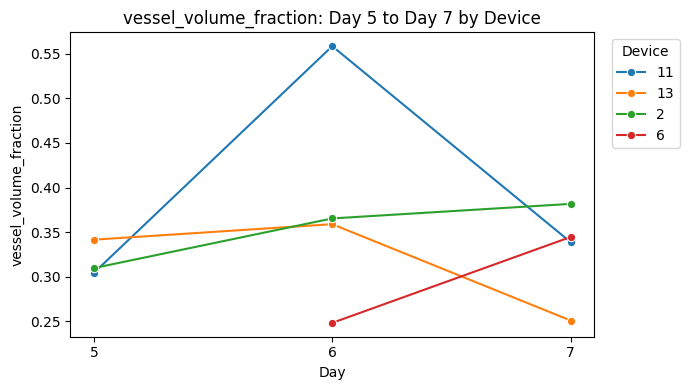

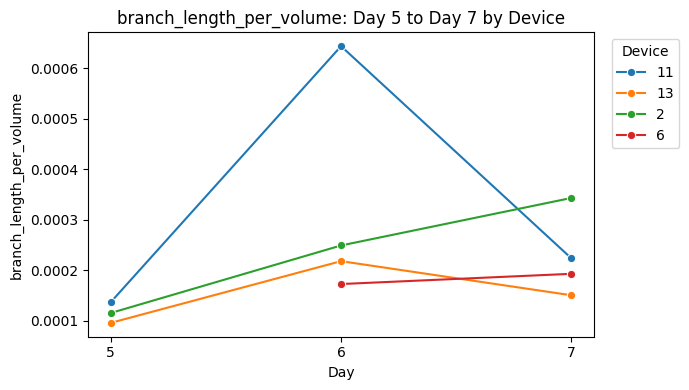

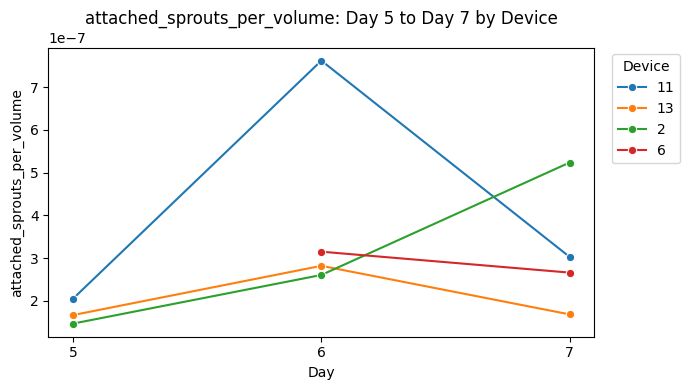

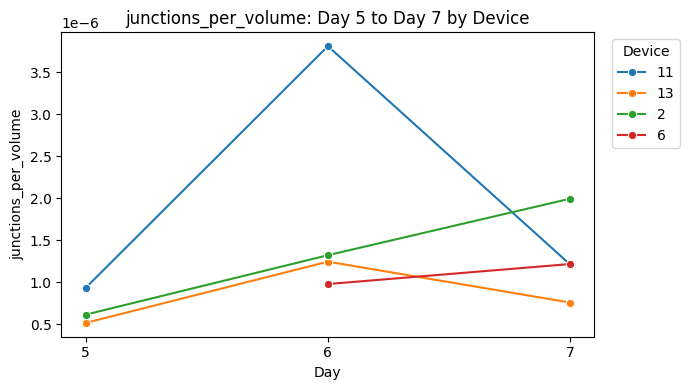

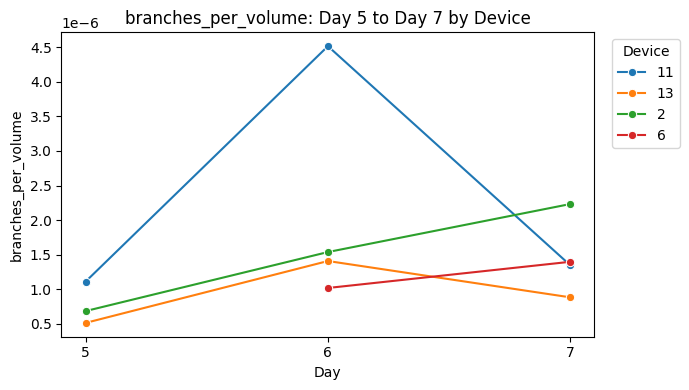

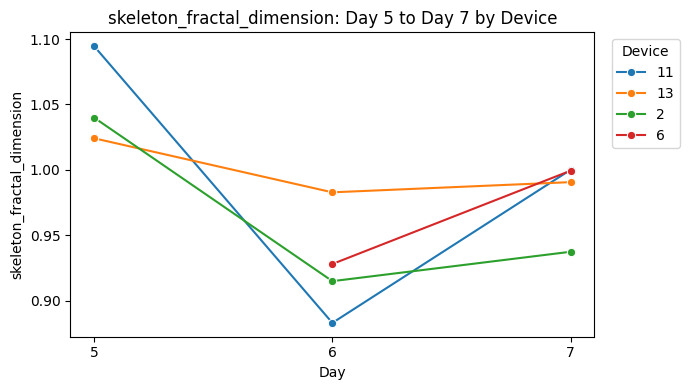

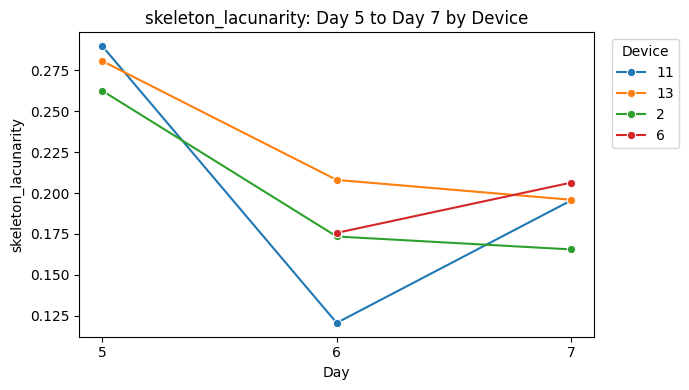

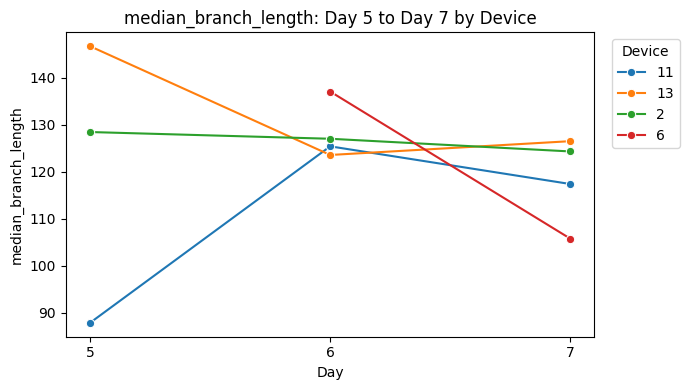

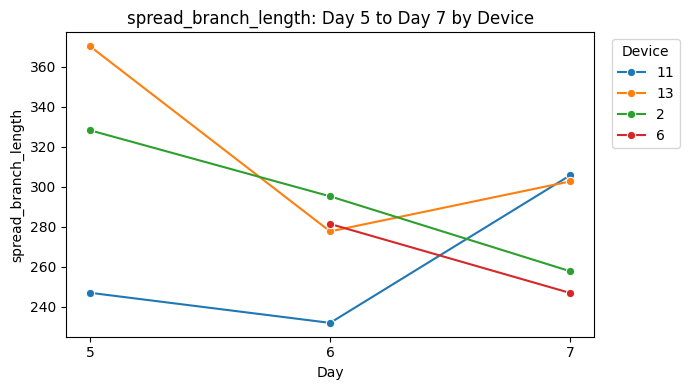

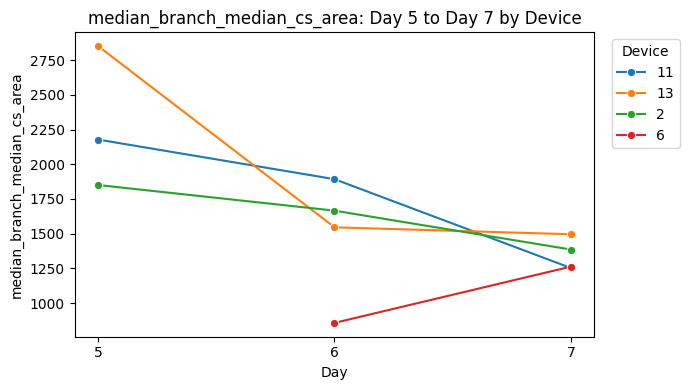

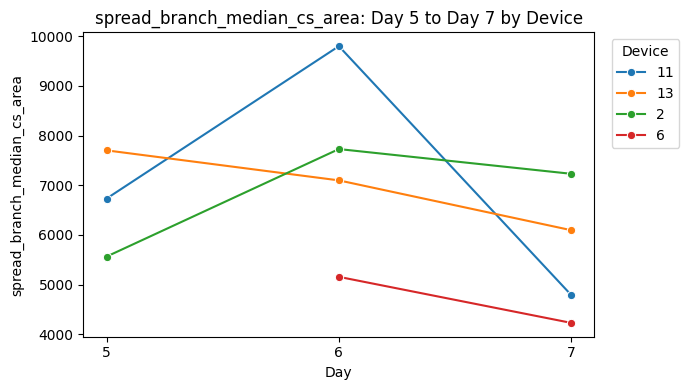

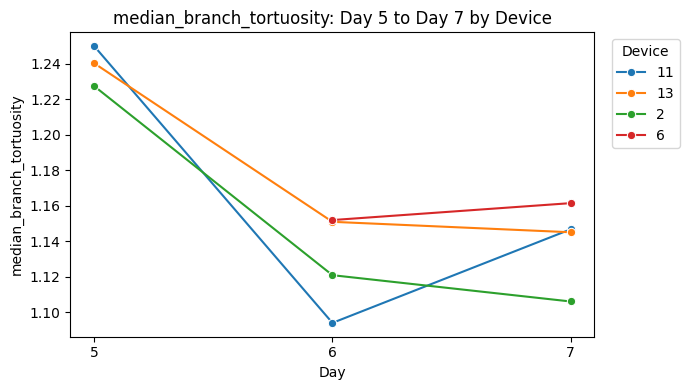

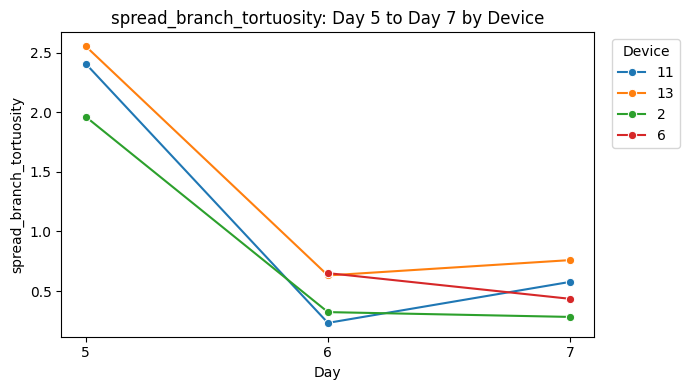

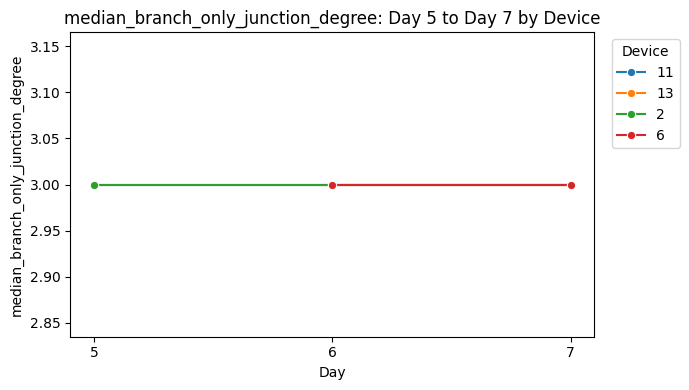

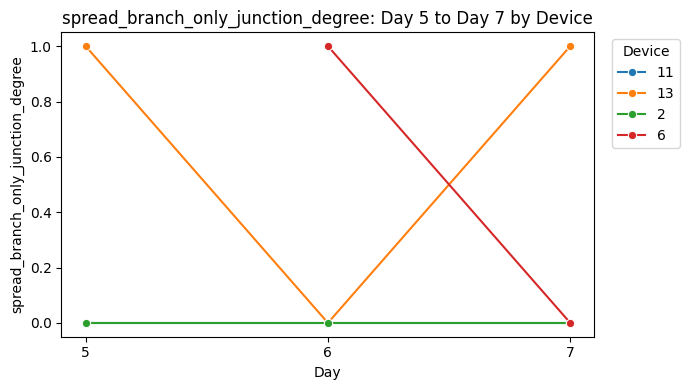

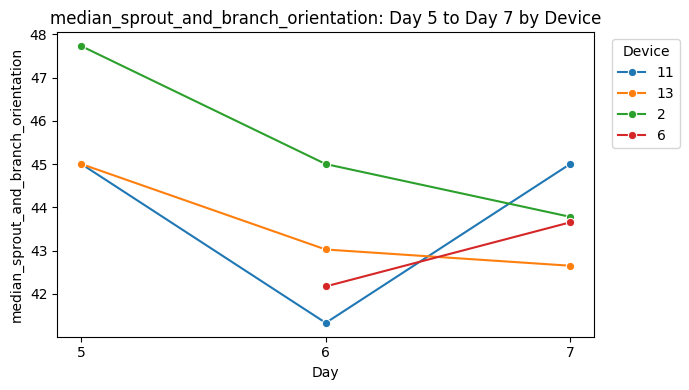

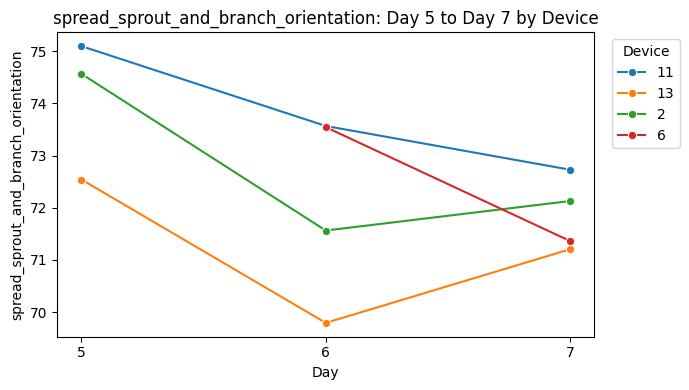

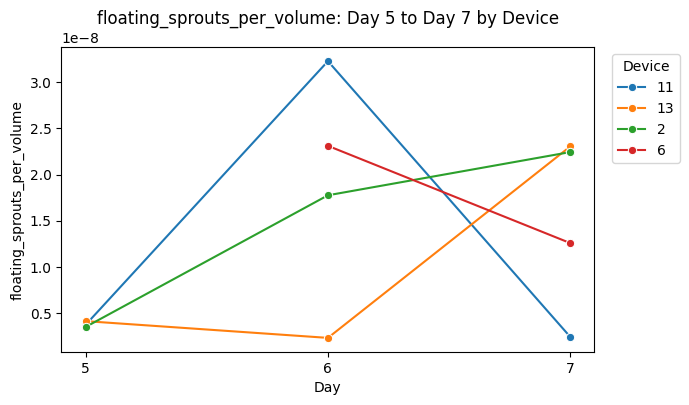

In [ ]:
# Ensure day/device are typed consistently for grouping and plotting
plot_df = data_csv.copy()
plot_df['day'] = pd.to_numeric(plot_df['day'], errors='coerce')
plot_df['device'] = plot_df['device'].astype(str)

# Keep only day 5, 6, 7
plot_df = plot_df[plot_df['day'].isin([5, 6, 7])].copy()

# All numeric parameters except metadata/grouping columns
exclude_cols = {'day', 'device', 'image_index'}
param_cols = [
    c for c in plot_df.select_dtypes(include='number').columns
    if c not in exclude_cols
]

# Mean parameter value for each device-day combination
grouped = (
    plot_df
    .groupby(['device', 'day'], as_index=False)[param_cols]
    .mean(numeric_only=True)
)

# Make one plot per parameter showing day trend for each device
for param in param_cols:
    plt.figure(figsize=(7, 4))
    sns.lineplot(
        data=grouped,
        x='day',
        y=param,
        hue='device',
        marker='o',
        errorbar=None
    )
    plt.xticks([5, 6, 7])
    plt.title(f'{param}: Day 5 to Day 7 by Device')
    plt.xlabel('Day')
    plt.ylabel(param)
    plt.legend(title='Device', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [7]:
param_cols

['vessel_volume_fraction',
 'branch_length_per_volume',
 'attached_sprouts_per_volume',
 'junctions_per_volume',
 'branches_per_volume',
 'skeleton_fractal_dimension',
 'skeleton_lacunarity',
 'median_branch_length',
 'spread_branch_length',
 'median_branch_median_cs_area',
 'spread_branch_median_cs_area',
 'median_branch_tortuosity',
 'spread_branch_tortuosity',
 'median_branch_only_junction_degree',
 'spread_branch_only_junction_degree',
 'median_sprout_and_branch_orientation',
 'spread_sprout_and_branch_orientation',
 'floating_sprouts_per_volume']

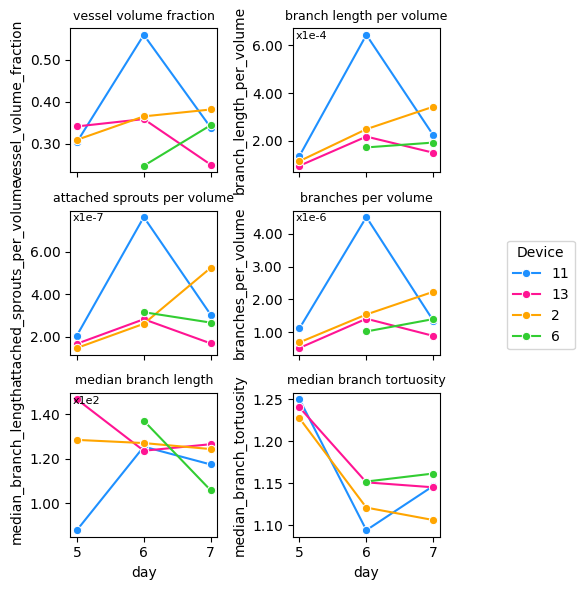

In [21]:
import numpy as np
import matplotlib.ticker as mticker

minimal_param_cols = [
    "vessel_volume_fraction",
    "branch_length_per_volume",
    "attached_sprouts_per_volume",
    "branches_per_volume",
    "median_branch_length",
    "median_branch_tortuosity",
]

# Make one plot per parameter showing day trend for each device in a 2x3 grid
palette = ["dodgerblue", "deeppink", "orange", "limegreen"]
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(5, 6), sharex=True)
flat_ax = ax.flatten()

for i, param in enumerate(minimal_param_cols):
    a = flat_ax[i]
    sns.lineplot(
        data=grouped,
        x='day',
        y=param,
        hue='device',
        marker='o',
        errorbar=None,
        ax=a,
        palette=palette
    )
    a.set_xticks([5, 6, 7])
    a.set_title(param.replace('_', ' '), fontsize=9)

    # Use max 2 decimal places for non-tortuosity axes and scientific scale when needed.
    if 'tortuosity' not in param.lower():
        vals = grouped[param].dropna().to_numpy()
        max_abs = np.nanmax(np.abs(vals)) if vals.size else 0
        if max_abs > 0:
            exp = int(np.floor(np.log10(max_abs)))
        else:
            exp = 0

        if abs(exp) >= 2:
            scale = 10 ** exp
            a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _, s=scale: f"{y / s:.2f}"))
            a.text(0.02, 0.98, f"x1e{exp}", transform=a.transAxes, ha='left', va='top', fontsize=8)
        else:
            a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Remove per-axis legends and add one shared legend for the whole figure
handles, labels = flat_ax[0].get_legend_handles_labels()
for a in flat_ax:
    legend = a.get_legend()
    if legend is not None:
        legend.remove()

fig.legend(handles, labels, title='Device', loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig("proof_of_principle.pdf")